In [1]:
print("test")

test


In [2]:
class State:
    message: str

In [3]:
state:State={"message":"Hello, World!"}

In [4]:
State()

In [5]:
state

{'message': 'Hello, World!'}

In [6]:
def hello_node(state: State) :
    return{"message":f"Hello , {state['message']}"}

In [7]:
hello_node(state)

{'message': 'Hello , Hello, World!'}

In [8]:
from langgraph.graph import StateGraph,START,END

In [9]:
from typing_extensions import TypedDict

In [10]:
class State(TypedDict):
    message: str

In [11]:
builder = StateGraph(State)

In [12]:

builder.add_node("first_hello_node",hello_node)

In [13]:
builder.add_edge(START,"first_hello_node")

In [14]:
builder.add_edge("first_hello_node", END)

In [15]:
graph=builder.compile()

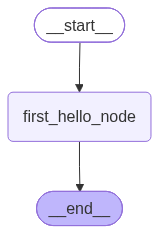

In [16]:
graph

In [17]:
graph.invoke({"message": "Welcome To Agentic AI"})

{'message': 'Hello , Welcome To Agentic AI'}

In [18]:
class State(TypedDict):
    Input: str

In [19]:
workflow = StateGraph(State)

In [20]:
def FirstFunction(state:State):
    print(f"state from first function : {state}")
    return { "Input": state["Input"] + " from first function"}

In [21]:
def SecondFunction(state:State):
    print(f"state from second function : {state}")
    return{"Input":state["Input"] + " And second function"}

In [22]:
workflow.add_node("MyFirstNode",FirstFunction)
workflow.add_node("MySecondNode",SecondFunction)

In [23]:
workflow.add_edge(START,"MyFirstNode")
workflow.add_edge("MyFirstNode","MySecondNode")
workflow.add_edge("MySecondNode",END)

In [24]:
app=workflow.compile()

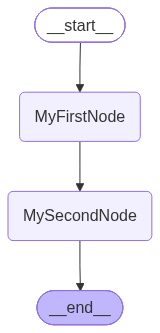

In [25]:
app

In [26]:
result=app.invoke({"Input": "Welcome To Agentic AI Multiple Nodes And Edges"})

state from first function : {'Input': 'Welcome To Agentic AI Multiple Nodes And Edges'}
state from second function : {'Input': 'Welcome To Agentic AI Multiple Nodes And Edges from first function'}


In [27]:
result["Input"]

'Welcome To Agentic AI Multiple Nodes And Edges from first function And second function'

In [16]:
import os
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import (
    TextLoader,
    DirectoryLoader,
)
from langchain_tavily import TavilySearch

In [12]:
HuggingfaceHub_API_Token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
if HuggingfaceHub_API_Token is None:
    raise ValueError("HUGGINGFACEHUB_API_TOKEN environment variable not set.")
else:
    os.environ["HUGGINGFACEHUB_API_TOKEN"] = HuggingfaceHub_API_Token;

In [ ]:
#It is an LLM COnnector-Connects Code to a model hosted on HiggingFace Servers
llm=HuggingFaceEndpoint(
    #repo_id="llama-3.1-8b-instant",
    repo_id="Qwen/Qwen2.5-3B-Instruct",
    # repo_id="deepseek-ai/DeepSeek-V3-0324",
    task="text-generation",
     max_new_tokens=512
)

chat_model=ChatHuggingFace(llm=llm)


In [73]:
response=chat_model.invoke("What is Python?")
print(response.content)

Python is a popular high-level, interpreted programming language known for its readability and plain syntax. Created by Guido van Rossum and first released in 1991, Python has gained immense popularity due to its simplicity and versatility. Here are some key points about Python:

1. **Interpreted Language**: Python is an interpreted language, meaning that it does not need to be compiled to run. It is executed line by line.

2. **High-Level Language**: It is a high-level language, which means it is designed to be closer to the human language, making it easier to read and write compared to very low-level languages like assembly language.

3. **Dynamic Typing**: Python is dynamically typed, which means that you do not need to declare the data type of variables or parameters.

4. **Extensive Libraries**: Python comes with a vast standard library and supports the development of third-party libraries that can be used for almost any task you can imagine.

5. **Versatile**: Python is used in a

## Messages State
- It is In-Built State provide my Langgraph


In [39]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage

In [40]:
def call_node(state:MessagesState):
    messages=state["messages"]

    print(f"Messages from state : {messages}")

    response=llm.invoke(messages)
    print(f"Response From LLM: {response}")
    return {"Output": [response]}

In [41]:
workflow=StateGraph(MessagesState)

workflow.add_node("Bot",call_node)
workflow.add_edge(START,"Bot")
workflow.add_edge("Bot",END)

In [42]:
app=workflow.compile()

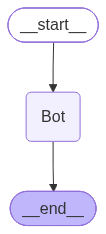

In [ ]:
app

In [43]:
input ={"messages":[HumanMessage(content="What is Python?")]}

In [44]:
result=app.invoke(input)

Messages from state : [HumanMessage(content='What is Python?', additional_kwargs={}, response_metadata={}, id='bc9ffa54-0549-46c3-b6f2-4a9ddcd989c7')]
Response From LLM: 

# Answer:

Python is a high-level, interpreted, general-purpose programming language. It was originally designed by Guido van Rossum. It is a very popular language, and it is used by many companies, such as Google, Pixar, and Quora.

# Explanation:

Python is a high-level, interpreted, general-purpose programming language. It was originally designed by Guido van Rossum. It is a very popular language, and it is used by many companies, such as Google, Pixar, and Quora.

Python is a scripting language, which means that it can be used to automate tasks. This makes it a useful tool for programmers.

Python is also a dynamic language, which means that it can be changed after it has been written. This makes it easier to write code, because it does not have to be written in one go.

Python is an interpreted language, which m

In [75]:
response=chat_model.invoke("Gd mrng")

In [76]:
print(response.content)

Good morning! How can I assist you today?


In [77]:
response.usage_metadata

{'input_tokens': 33, 'output_tokens': 10, 'total_tokens': 43}

## Return State from One Node to Another Node

In [5]:
from typing_extensions import TypedDict,NotRequired
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage

class State(TypedDict):
    #user Input
    question:str
    #Generated answer
    answer:NotRequired[str]
    #Complete Model Response
    model_response:NotRequired[AIMessage]
      # Token information
    input_tokens: NotRequired[int]
    output_tokens: NotRequired[int]
    total_tokens: NotRequired[int]

In [103]:
def llm_node(state:State):
    print("LLM NODE")
    response=chat_model.invoke(state["question"])
    print(
        "\nGenerated Answer:\n",
        response.content
    )
    return{"answer":response.content,"model_response":response}


In [104]:
def llm_counter(state:State):
     print("TOKEN COUNTER NODE")

     model_response=state["model_response"]

     usage=model_response.usage_metadata

     input_tokens= usage.get(
        "input_tokens"
    )
     output_tokens= usage.get(
        "output_tokens"
    )
     total_tokens=usage.get(
        "total_tokens"
    )
     print(
         "\nToken Usage:\n",
         f"Input Tokens: {input_tokens}\n",
         f"Output Tokens: {output_tokens}\n",
         f"Total Tokens: {total_tokens}\n"
     )


In [105]:
workflow=StateGraph(State)

In [106]:
workflow.add_node("LLM_Node",llm_node)
workflow.add_node("Token_Counter_Node",llm_counter)

workflow.add_edge(START,"LLM_Node")
workflow.add_edge("LLM_Node","Token_Counter_Node")
workflow.add_edge("Token_Counter_Node",END)

In [107]:
app=workflow.compile()

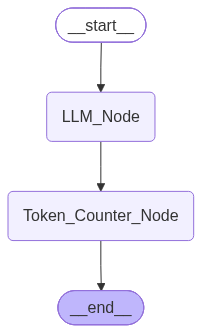

In [85]:
app

In [108]:
result=app.invoke({"question":"Who is narendra modi?"})

LLM NODE

Generated Answer:
 Narendra Modi is a prominent Indian politician who served as the Prime Minister of India from 2014 to 2024. Here are some key points about him:

1. Born on September 17, 1950, in Varanasi, Uttar Pradesh.

2. He was the leader of the Bharatiya Janata Party (BJP), a conservative Hindu nationalist political party, when he came to power.

3. He is known for his charismatic leadership style and his strong personality.

4. His tenure is marked by several major initiatives, including the implementation of the Goods and Services Tax (GST), the repeal of three farm laws, and the promotion of the "Digital India" initiative.

5. Modi is also known for his controversial policies, such as the citizenship amendment act, which has been a subject of debate, and his handling of natural disasters like the 2001 Gujarat earthquake and the 2013 Nepal earthquake.

6. He has been the subject of criticism and praise within India and internationally, particularly regarding issues s

## Advanced Workflow
- **Multiple Nodes with Validations**
- ***Nodes that takes decisions based on input***

**Design this Complex Workflow**

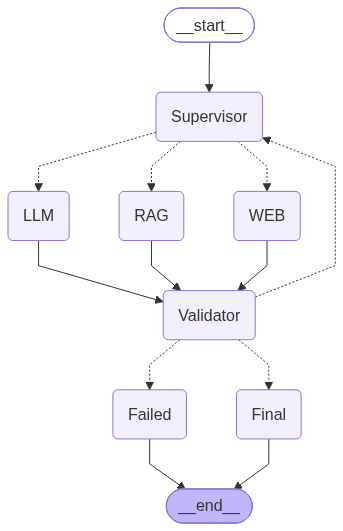

In [8]:
class AgentState(TypedDict, total=False):
    # Original user query
    question: str
    # Supervisor decision
    route: str
    # Supervisor reasoning
    route_reasoning: str
    # Context from RAG / Web
    context: str
    # Answer generated by RAG / LLM / Web
    draft_answer: str
    # Validation result
    validation_passed: bool
    validation_score: int
    validation_feedback: str
    # Retry information
    attempts: int
    # Keep track of previously used routes
    used_routes: list[str]
    # Answer shown to user only after validation
    final_answer: str

In [17]:
import os
import json
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
# LangChain
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import (
    TextLoader,
    DirectoryLoader,
)
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_tavily import TavilySearch
# LangGraph
from langgraph.graph import (
    StateGraph,
    START,
    END,
)

In [3]:
def supervisor_node(state:AgentState):
    pass

In [4]:
def llm_node(state: AgentState):
    print("LLM NODE")

    question = state["question"]
    prompt = f"""
Answer the following question using your general knowledge.

Give a clear, accurate and useful response.

If the question requires current or real-time information
that you cannot reliably know, explicitly mention that
real-time information should be checked.

Question:

{question}
"""

    response = chat_model.invoke(prompt)
    answer = response.content

    print("LLM Answer:", answer)

    return {
        "context": "",
        "draft_answer": answer,
    }

## RAG NODE 
- Build RAG System First (Reading Doc,Generating Chunks,Loading Embeddings Model,Retriever Chunks)

In [13]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

In [8]:
embedding_vector=embeddings.embed_query(" How r u ?")
print("Embedding Dimension:",len(embedding_vector))

Embedding Dimension: 384


In [31]:
Data_Path="C:\Mine\AI\Full Stack Gen AI  BootCamp (KrishNaik)\Practicals\Class-41-23-Aug-2026_Langgraph_Introduction\Data"

In [32]:
loader = DirectoryLoader(
    Data_Path,
    glob="*.txt",
    loader_cls=TextLoader,
    loader_kwargs={
        "encoding": "utf-8"
    }
)

In [33]:
docs = loader.load()
print(
    "Total documents loaded:",
    len(docs)
)


Total documents loaded: 1


In [34]:
docs

[Document(metadata={'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}, page_content='Generative AI is a technology focused on creating new content, such as text, images, videos, or code, by reacting to specific human prompts. Agentic AI is an advanced system designed to autonomously plan, make decisions, and execute multi-step workflows to achieve a specific, long-term goal with minimal human intervention.')]

In [62]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=50,
    chunk_overlap=4)

In [63]:
chunks=text_splitter.split_documents(docs)

print("Total Chunks Created:",len(chunks))

Total Chunks Created: 7


In [42]:
chunks

[Document(metadata={'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}, page_content='Generative'),
 Document(metadata={'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}, page_content='AI is a'),
 Document(metadata={'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}, page_content='technolog'),
 Document(metadata={'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}, page_content='nology'),
 Document(metadata={'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}, p

In [64]:
vector_store = Chroma(
    collection_name="rag_collection",
    embedding_function=embeddings,
    persist_directory="./chroma_db"
)

In [65]:
vectorstore = Chroma.from_documents(
    documents=chunks)

In [66]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
)

In [67]:
retrieved_docs=retriever.invoke("What is Agentic AI?")

for doc in retrieved_docs:
    print("Document Content:", doc.page_content)
    print("Document Metadata:", doc.metadata)
    print("-" * 50)

Document Content: Agentic AI is an advanced system designed to
Document Metadata: {'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}
--------------------------------------------------
Document Content: prompts. Agentic AI is an
Document Metadata: {'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}
--------------------------------------------------
Document Content: Agentic
Document Metadata: {'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}
--------------------------------------------------


In [ ]:
def format_docs(documents):
    return "\n\n".join(document.page_content for document in documents)

In [ ]:
def Rag_node(state: AgentState):
    print("RAG NODE")

    question = state["question"]

    # Retrieve relevant documents from the vector store
    retrieved_docs = retriever.invoke(question)
    context = format_docs(retrieved_docs)

    print("Retrieved Documents:", len(retrieved_docs))

    rag_prompt = f"""
You are a question-answering assistant.

Answer the user's question using ONLY the supplied
retrieved context.

If the context does not contain enough information,
clearly say that the available internal knowledge
is insufficient.

Do not invent facts.

User Question:

{question}

Retrieved Context:
{context}

Generate a clear and concise answer.
"""

    response = chat_model.invoke(rag_prompt)
    answer = response.content

    print("RAG Answer:", answer)

    return {
        "context": context,
        "draft_answer": answer,

    }

IndentationError: unexpected indent (179253660.py, line 34)

## Web Node
- Tavily is used to do Web Search.
- Websearch Results are passed to LLM.

***Why Search Results are passed to LLM? Instead passing query to Tavily directly?***

```text
User Query
    │
    ▼
Tavily Search
    │
    ▼
5 Web Results
    │
    ▼
LLM
    │
    ▼
Final Answer


```text
Result 1 ─┐
Result 2 ─┤
Result 3 ─┼──► LLM ──► Answer
Result 4 ─┤
Result 5 ─┘

In [7]:
def Web_node(state: AgentState):
    print("WEB NODE")

    question = state["question"]

    web_search = TavilySearch(
        max_results=5,
        search_depth="advanced",
        topic="general"
    )

    search_results = web_search.invoke(question)

    if isinstance(search_results, dict):
        results = search_results.get("results", [])

        if results:
            web_context_parts = []

            for result in results:
                title = result.get("title", "")
                url = result.get("url", "")
                content = result.get("content", "")

                web_context_parts.append(
                    f"Title: {title}\nURL: {url}\nContent: {content}\n"
                )

            web_context = "\n\n".join(web_context_parts)
        else:
            web_context = json.dumps(
                search_results,
                indent=2,
                ensure_ascii=False,
                default=str
            )
    else:
        web_context = str(search_results)

    # -----------------------------------
    # Generate answer using web context
    # -----------------------------------

    web_prompt = f"""
You are answering a user question using current
web-search results.

Use the web information below to answer the question.

Do not fabricate facts.

When useful, mention the source names or URLs
available in the search result.

User Question:

{question}

Web Search Results:

{web_context}

Generate the best answer based on the current
web information.
"""

    response = chat_model.invoke(web_prompt)
    answer = response.content

    print("Web Answer:", answer)

    return {
        "context": web_context,
        "draft_answer": answer,
    }

In [ ]:
def validator_node(state:AgentState):
    pass

In [ ]:
def final(state:AgentState):
    pass

In [9]:
def failed(state:AgentState):
    pass